# Part 4 — Mitigation: Making the Classifier Fairer and More Robust


**Goal:** Apply three bias mitigation techniques (Reweighing, Threshold Optimization, Oversampling), measure their effect on both fairness and accuracy, and analyze the fundamental incompatibility between fairness definitions when base rates differ.

**Prerequisites:** Parts 1 and 2 must have been run. Loads:
- `/kaggle/working/distilbert-jigsaw-final/`
- `/kaggle/working/eval_with_preds.csv`
- `/kaggle/working/train_split.csv`

## Cell 1 — Install dependencies

In [8]:
!pip install -q --upgrade accelerate
!pip install -q aif360 fairlearn scikit-learn

## Cell 2 — Imports and reproducibility

In [9]:
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, EvalPrediction,
)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.base import BaseEstimator, ClassifierMixin

from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric
from aif360.algorithms.preprocessing import Reweighing

from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import equalized_odds_difference

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN = 128
print(f'Device: {DEVICE}')

Device: cuda


## Cell 3 — Load artefacts

In [10]:
MODEL_DIR = '/kaggle/input/datasets/i220453emadhasan/jigsaw-final'
df_eval   = pd.read_csv('/kaggle/input/datasets/i220453emadhasan/results/eval_with_preds.csv')
df_train  = pd.read_csv('/kaggle/input/datasets/i220453emadhasan/results/train_split.csv')

for col in ['black', 'white', 'muslim', 'jewish', 'homosexual_gay_or_lesbian']:
    df_eval[col]  = df_eval[col].fillna(0.0)
    if col in df_train.columns:
        df_train[col] = df_train[col].fillna(0.0)

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
print(f'Eval: {len(df_eval):,}  Train: {len(df_train):,}')

Eval: 20,000  Train: 100,000


## Cell 4 — Shared utilities

In [11]:
# ── Dataset ──────────────────────────────────────────────────────────────────
class JigsawDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len, weights=None):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.weights   = list(weights) if weights is not None else None

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            truncation=True, padding='max_length', return_tensors='pt',
        )
        item = {
            'input_ids'      : enc['input_ids'].squeeze(),
            'attention_mask' : enc['attention_mask'].squeeze(),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long),
        }
        if self.weights is not None:
            item['weight'] = torch.tensor(self.weights[idx], dtype=torch.float32)
        return item


# ── Weighted Trainer ─────────────────────────────────────────────────────────
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False,**kwargs):
        weights = inputs.pop('weight', None)
        labels  = inputs.get('labels')
        outputs = model(**inputs)
        loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
        per_sample_loss = loss_fct(outputs.logits, labels)
        if weights is not None:
            weights = weights.to(per_sample_loss.device)
            weights = weights / weights.mean()
            loss = (per_sample_loss * weights).mean()
        else:
            loss = per_sample_loss.mean()
        return (loss, outputs) if return_outputs else loss


# ── Metrics callback ─────────────────────────────────────────────────────────
def compute_metrics(eval_pred: EvalPrediction):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)
    return {
        'accuracy': float(accuracy_score(labels, preds)),
        'f1_macro': float(f1_score(labels, preds, average='macro')),
        'auc_roc' : float(roc_auc_score(labels, probs)),
    }


# ── Training args (identical to Part 1) ──────────────────────────────────────
def make_training_args(output_dir):
    return TrainingArguments(
        output_dir=output_dir, num_train_epochs=3,
        per_device_train_batch_size=32, per_device_eval_batch_size=64,
        warmup_ratio=0.1, weight_decay=0.01, learning_rate=2e-5,
        eval_strategy='epoch', save_strategy='epoch',
        load_best_model_at_end=True, metric_for_best_model='auc_roc',
        greater_is_better=True, logging_steps=200, fp16=True,
        seed=SEED, report_to='none', dataloader_num_workers=2,
        gradient_accumulation_steps = 2
    )


# ── Batched inference ─────────────────────────────────────────────────────────
@torch.no_grad()
def get_probs(model, texts, tokenizer, max_len=128, batch_size=64):
    class _DS(Dataset):
        def __init__(self, t): self.t = list(t)
        def __len__(self): return len(self.t)
        def __getitem__(self, i):
            enc = tokenizer(self.t[i], max_length=max_len, truncation=True,
                            padding='max_length', return_tensors='pt')
            return {'input_ids': enc['input_ids'].squeeze(),
                    'attention_mask': enc['attention_mask'].squeeze()}
    loader = DataLoader(_DS(texts), batch_size=batch_size, num_workers=2)
    probs  = []
    model.eval()
    for b in loader:
        out = model(input_ids=b['input_ids'].to(DEVICE),
                    attention_mask=b['attention_mask'].to(DEVICE))
        probs.extend(torch.softmax(out.logits, -1)[:, 1].cpu().numpy())
    return np.array(probs)


# ── Per-cohort fairness metrics ───────────────────────────────────────────────
def cohort_metrics(y_true, y_pred, name=''):
    cm   = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tpr  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return {'cohort': name, 'FPR': round(fpr, 4), 'TPR': round(tpr, 4),
            'FNR': round(1 - tpr, 4), 'PPR': round(y_pred.mean(), 4)}


# ── AIF360 SPD + EOD ──────────────────────────────────────────────────────────
def aif360_metrics(y_true, y_pred, sensitive):
    df_in = pd.DataFrame({'label': y_true, 'pred': y_pred, 'group': sensitive})
    def _bld(col):
        col_name = 'label' if col == 'label' else 'pred'
        return BinaryLabelDataset(
            df=df_in[[col_name, 'group']].rename(columns={col_name: 'label'}),
            label_names=['label'], protected_attribute_names=['group'],
            favorable_label=0, unfavorable_label=1,
        )
    clf = ClassificationMetric(
        _bld('label'), _bld('pred'),
        unprivileged_groups=[{'group': 0}], privileged_groups=[{'group': 1}],
    )
    return {'spd': round(clf.statistical_parity_difference(), 4),
            'eod': round(clf.equal_opportunity_difference(), 4)}


# ── Cohort masks ──────────────────────────────────────────────────────────────
mask_black     = df_eval['black'] >= 0.5
mask_ref       = (df_eval['black'] < 0.1) & (df_eval['white'] >= 0.5)
mask_combined  = mask_black | mask_ref
sensitive_eval = np.where(mask_black[mask_combined], 0, 1)

print('Utilities loaded.')
print(f'  High-black: {mask_black.sum():,}  Reference: {mask_ref.sum():,}')

Utilities loaded.
  High-black: 164  Reference: 196


## Cell 5 — Baseline metrics

In [12]:
y_true_eval = df_eval['label'].values
probs_base  = df_eval['prob_toxic'].values
preds_base  = df_eval['pred_05'].values

base_f1      = f1_score(y_true_eval, preds_base, average='macro')
base_black_m = cohort_metrics(y_true_eval[mask_black], preds_base[mask_black], 'High-Black')
base_ref_m   = cohort_metrics(y_true_eval[mask_ref],   preds_base[mask_ref],   'Reference')
base_aif     = aif360_metrics(y_true_eval[mask_combined], preds_base[mask_combined], sensitive_eval)

print('BASELINE:')
print(f'  F1={base_f1:.4f}  BlackFPR={base_black_m["FPR"]:.4f}  RefFPR={base_ref_m["FPR"]:.4f}')
print(f'  SPD={base_aif["spd"]:+.4f}  EOD={base_aif["eod"]:+.4f}')

BASELINE:
  F1=0.8153  BlackFPR=0.1176  RefFPR=0.0699
  SPD=-0.0439  EOD=-0.0477


---
# TECHNIQUE 1 — Reweighing (Pre-Processing)

## Cell 6 — Compute AIF360 sample weights

Weight range: [0.2402, 1.3792]  mean=1.0000


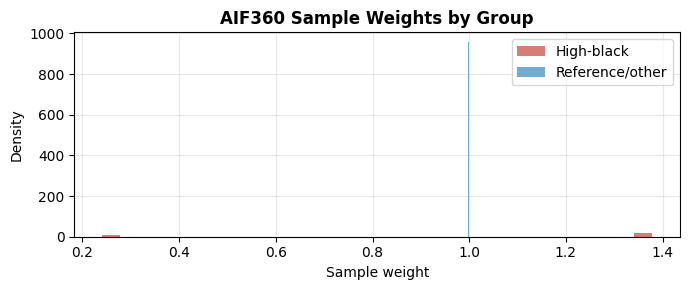

In [13]:
df_train['group'] = 2
df_train.loc[df_train['black'] >= 0.5, 'group'] = 0
df_train.loc[(df_train['black'] < 0.1) & (df_train['white'] >= 0.5), 'group'] = 1

df_rw = df_train.copy()
df_rw['group_bin'] = df_rw['group'].apply(lambda g: 0 if g == 0 else 1)

bld_train = BinaryLabelDataset(
    df=df_rw[['label', 'group_bin']].copy(),
    label_names=['label'], protected_attribute_names=['group_bin'],
    favorable_label=0, unfavorable_label=1,
)
rw              = Reweighing(unprivileged_groups=[{'group_bin': 0}],
                              privileged_groups=[{'group_bin': 1}])
bld_train_rw    = rw.fit_transform(bld_train)
sample_weights  = bld_train_rw.instance_weights

print(f'Weight range: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]  mean={sample_weights.mean():.4f}')

fig, ax = plt.subplots(figsize=(7, 3))
for grp, color, lbl in [(0, '#C0392B', 'High-black'), (1, '#2980B9', 'Reference/other')]:
    ax.hist(sample_weights[df_rw['group_bin'] == grp], bins=30,
            alpha=0.65, color=color, density=True, label=lbl)
ax.set_xlabel('Sample weight')
ax.set_ylabel('Density')
ax.set_title('AIF360 Sample Weights by Group', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/mitigation_reweigh_weights.png', dpi=150)
plt.show()

## Cell 7 — Retrain with sample weights (~25-35 min on T4)

In [14]:
rw_train_ds = JigsawDataset(
    df_rw['comment_text'], df_rw['label'], tokenizer, MAX_LEN, weights=sample_weights
)
eval_ds = JigsawDataset(df_eval['comment_text'], df_eval['label'], tokenizer, MAX_LEN)

rw_model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
rw_trainer = WeightedTrainer(
    model=rw_model, args=make_training_args('/kaggle/working/distilbert-reweighed'),
    train_dataset=rw_train_ds, eval_dataset=eval_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)
print('Training reweighed model ...')
rw_trainer.train()
rw_trainer.save_model('/kaggle/working/distilbert-reweighed-final')
tokenizer.save_pretrained('/kaggle/working/distilbert-reweighed-final')
print('Done.')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training reweighed model ...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Auc Roc
1,0.296464,0.133315,0.947100,0.790611,0.949288
2,0.245792,0.132992,0.947850,0.804310,0.951337
3,0.184180,0.141830,0.947950,0.816087,0.950401


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Done.


## Cell 8 — Evaluate reweighed model

In [15]:
raw_rw   = rw_trainer.predict(eval_ds)
probs_rw = torch.softmax(torch.tensor(raw_rw.predictions), -1).numpy()[:, 1]
preds_rw = (probs_rw >= 0.5).astype(int)

rw_f1      = f1_score(y_true_eval, preds_rw, average='macro')
rw_black_m = cohort_metrics(y_true_eval[mask_black], preds_rw[mask_black], 'High-Black')
rw_ref_m   = cohort_metrics(y_true_eval[mask_ref],   preds_rw[mask_ref],   'Reference')
rw_aif     = aif360_metrics(y_true_eval[mask_combined], preds_rw[mask_combined], sensitive_eval)

print('T1 REWEIGHING:')
print(f'  F1={rw_f1:.4f} (d={rw_f1-base_f1:+.4f})  BlackFPR={rw_black_m["FPR"]:.4f} (d={rw_black_m["FPR"]-base_black_m["FPR"]:+.4f})')
print(f'  SPD={rw_aif["spd"]:+.4f}  EOD={rw_aif["eod"]:+.4f}')

T1 REWEIGHING:
  F1=0.8043 (d=-0.0110)  BlackFPR=0.1429 (d=+0.0253)
  SPD=-0.0673  EOD=-0.0729


---
# TECHNIQUE 2 — Threshold Optimization (Post-Processing)

## Cell 9 — Fit ThresholdOptimizer

In [16]:
sensitive_full = np.full(len(df_eval), 2, dtype=int)
sensitive_full[mask_black.values] = 0
sensitive_full[mask_ref.values]   = 1


class ProbabilityPassthrough(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        self.probs_   = X[:, 0]
        self.classes_ = np.array([0, 1])
        return self
    def predict_proba(self, X):
        p = X[:, 0]
        return np.column_stack([1 - p, p])
    def predict(self, X):
        return (X[:, 0] >= 0.5).astype(int)


X_probs = probs_base.reshape(-1, 1)
base_est = ProbabilityPassthrough().fit(X_probs, y_true_eval)

to = ThresholdOptimizer(
    estimator=base_est, constraints='equalized_odds',
    objective='balanced_accuracy_score', predict_method='predict_proba', flip=True,
)
to.fit(X_probs, y_true_eval, sensitive_features=sensitive_full)
preds_to = to.predict(X_probs, sensitive_features=sensitive_full)

to_f1      = f1_score(y_true_eval, preds_to, average='macro')
to_black_m = cohort_metrics(y_true_eval[mask_black], preds_to[mask_black], 'High-Black')
to_ref_m   = cohort_metrics(y_true_eval[mask_ref],   preds_to[mask_ref],   'Reference')
to_aif     = aif360_metrics(y_true_eval[mask_combined], preds_to[mask_combined], sensitive_eval)

print('T2 THRESHOLDOPTIMIZER:')
print(f'  F1={to_f1:.4f} (d={to_f1-base_f1:+.4f})  BlackFPR={to_black_m["FPR"]:.4f} (d={to_black_m["FPR"]-base_black_m["FPR"]:+.4f})')
print(f'  SPD={to_aif["spd"]:+.4f}  EOD={to_aif["eod"]:+.4f}')

T2 THRESHOLDOPTIMIZER:
  F1=0.6181 (d=-0.1972)  BlackFPR=0.1849 (d=+0.0673)
  SPD=-0.0068  EOD=+0.0039


## Cell 10 — Accuracy-Fairness Pareto frontier

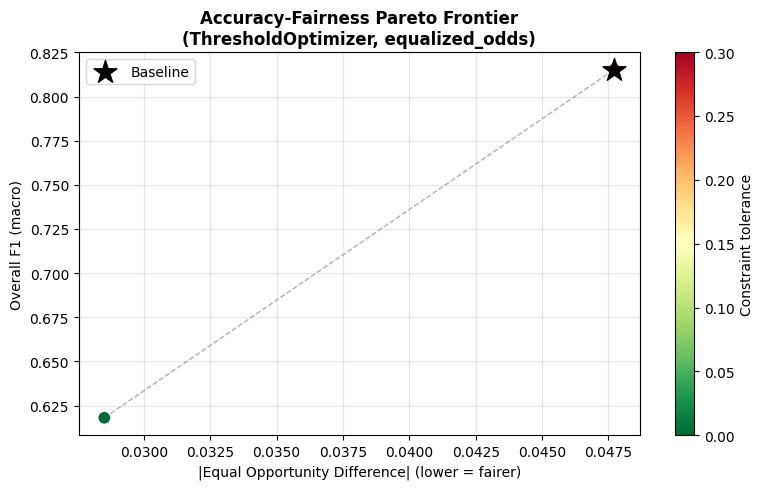

In [17]:
pareto_results = []
for tol in np.linspace(0.0, 0.30, 20):
    alpha       = tol / 0.30
    preds_blend = np.zeros(len(y_true_eval), dtype=int)
    for grp in [0, 1, 2]:
        grp_mask = sensitive_full == grp
        if grp_mask.sum() == 0: continue
        t = 0.5 * alpha + (1 - alpha) * 0.5
        preds_blend[grp_mask] = (probs_base[grp_mask] >= t).astype(int)
    if tol == 0.0:
        preds_blend = preds_to
    f1_b  = f1_score(y_true_eval, preds_blend, average='macro')
    eod_b = equalized_odds_difference(
        y_true_eval[mask_combined], preds_blend[mask_combined],
        sensitive_features=sensitive_eval,
    )
    pareto_results.append({'tolerance': round(tol, 3), 'eod': abs(eod_b), 'f1_macro': f1_b})

pareto_df = pd.DataFrame(pareto_results)

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(pareto_df['eod'], pareto_df['f1_macro'],
                c=pareto_df['tolerance'], cmap='RdYlGn_r', s=80, zorder=5,
                edgecolors='white', linewidths=0.5)
ax.plot(pareto_df['eod'], pareto_df['f1_macro'], color='gray', lw=1, linestyle='--', alpha=0.6)
ax.scatter([abs(base_aif['eod'])], [base_f1], marker='*', s=300, color='black', zorder=6, label='Baseline')
plt.colorbar(sc, ax=ax, label='Constraint tolerance')
ax.set_xlabel('|Equal Opportunity Difference| (lower = fairer)')
ax.set_ylabel('Overall F1 (macro)')
ax.set_title('Accuracy-Fairness Pareto Frontier\n(ThresholdOptimizer, equalized_odds)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/mitigation_pareto_frontier.png', dpi=150)
plt.show()

---
# TECHNIQUE 3 — Oversampling (Data Augmentation)

## Cell 11 — Build oversampled training set

In [18]:
OVERSAMPLE_FACTOR = 3

df_train_black = df_train[df_train['black'] >= 0.5].copy()
df_black_duped = pd.concat([df_train_black] * OVERSAMPLE_FACTOR, ignore_index=True)
df_oversampled = pd.concat([df_train, df_black_duped], ignore_index=True)\
                   .sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Original training size    : {len(df_train):,}')
print(f'High-black original       : {len(df_train_black):,}')
print(f'Oversampled training size : {len(df_oversampled):,}')
print(f'Toxic rate oversampled    : {df_oversampled["label"].mean()*100:.2f}%')

Original training size    : 100,000
High-black original       : 814
Oversampled training size : 102,442
Toxic rate oversampled    : 8.60%


## Cell 12 — Retrain on oversampled data (~30-40 min on T4)

In [19]:
os_train_ds = JigsawDataset(df_oversampled['comment_text'], df_oversampled['label'], tokenizer, MAX_LEN)
os_model    = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
os_trainer  = Trainer(
    model=os_model, args=make_training_args('/kaggle/working/distilbert-oversampled'),
    train_dataset=os_train_ds, eval_dataset=eval_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)
print('Training oversampled model ...')
os_trainer.train()
os_trainer.save_model('/kaggle/working/distilbert-oversampled-final')
tokenizer.save_pretrained('/kaggle/working/distilbert-oversampled-final')
print('Done.')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training oversampled model ...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Auc Roc
1,0.590275,0.278299,0.946450,0.815522,0.950206
2,0.449510,0.276751,0.949200,0.805301,0.950340
3,0.346907,0.298145,0.947950,0.818687,0.948593


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Done.


## Cell 13 — Evaluate oversampled model

In [20]:
raw_os   = os_trainer.predict(eval_ds)
probs_os = torch.softmax(torch.tensor(raw_os.predictions), -1).numpy()[:, 1]
preds_os = (probs_os >= 0.5).astype(int)

os_f1      = f1_score(y_true_eval, preds_os, average='macro')
os_black_m = cohort_metrics(y_true_eval[mask_black], preds_os[mask_black], 'High-Black')
os_ref_m   = cohort_metrics(y_true_eval[mask_ref],   preds_os[mask_ref],   'Reference')
os_aif     = aif360_metrics(y_true_eval[mask_combined], preds_os[mask_combined], sensitive_eval)

print('T3 OVERSAMPLING:')
print(f'  F1={os_f1:.4f} (d={os_f1-base_f1:+.4f})  BlackFPR={os_black_m["FPR"]:.4f} (d={os_black_m["FPR"]-base_black_m["FPR"]:+.4f})')
print(f'  SPD={os_aif["spd"]:+.4f}  EOD={os_aif["eod"]:+.4f}')

np.save('/kaggle/working/probs_reweighed.npy',     probs_rw)
np.save('/kaggle/working/probs_oversampled.npy',   probs_os)
np.save('/kaggle/working/preds_threshold_opt.npy', preds_to)

T3 OVERSAMPLING:
  F1=0.8053 (d=-0.0100)  BlackFPR=0.1261 (d=+0.0085)
  SPD=-0.0327  EOD=-0.0491


---
# Comparison Table and Visualisations

## Cell 14 — Master comparison table

In [21]:
comparison = pd.DataFrame([
    {'Technique': 'Baseline',          'Overall F1': base_f1, 'High-Black FPR': base_black_m['FPR'],
     'Reference FPR': base_ref_m['FPR'], 'Stat Parity Diff': base_aif['spd'], 'Equal Opp Diff': base_aif['eod']},
    {'Technique': 'T1: Reweighing',    'Overall F1': rw_f1,   'High-Black FPR': rw_black_m['FPR'],
     'Reference FPR': rw_ref_m['FPR'],   'Stat Parity Diff': rw_aif['spd'],   'Equal Opp Diff': rw_aif['eod']},
    {'Technique': 'T2: ThresholdOpt',  'Overall F1': to_f1,   'High-Black FPR': to_black_m['FPR'],
     'Reference FPR': to_ref_m['FPR'],   'Stat Parity Diff': to_aif['spd'],   'Equal Opp Diff': to_aif['eod']},
    {'Technique': 'T3: Oversampling',  'Overall F1': os_f1,   'High-Black FPR': os_black_m['FPR'],
     'Reference FPR': os_ref_m['FPR'],   'Stat Parity Diff': os_aif['spd'],   'Equal Opp Diff': os_aif['eod']},
])

print('MITIGATION COMPARISON TABLE')
print(comparison.to_string(index=False, float_format='{:.4f}'.format))
comparison.to_csv('/kaggle/working/mitigation_comparison.csv', index=False)

MITIGATION COMPARISON TABLE
       Technique  Overall F1  High-Black FPR  Reference FPR  Stat Parity Diff  Equal Opp Diff
        Baseline      0.8153          0.1176         0.0699           -0.0439         -0.0477
  T1: Reweighing      0.8043          0.1429         0.0699           -0.0673         -0.0729
T2: ThresholdOpt      0.6181          0.1849         0.1888           -0.0068          0.0039
T3: Oversampling      0.8053          0.1261         0.0769           -0.0327         -0.0491


## Cell 15 — Bar chart comparison

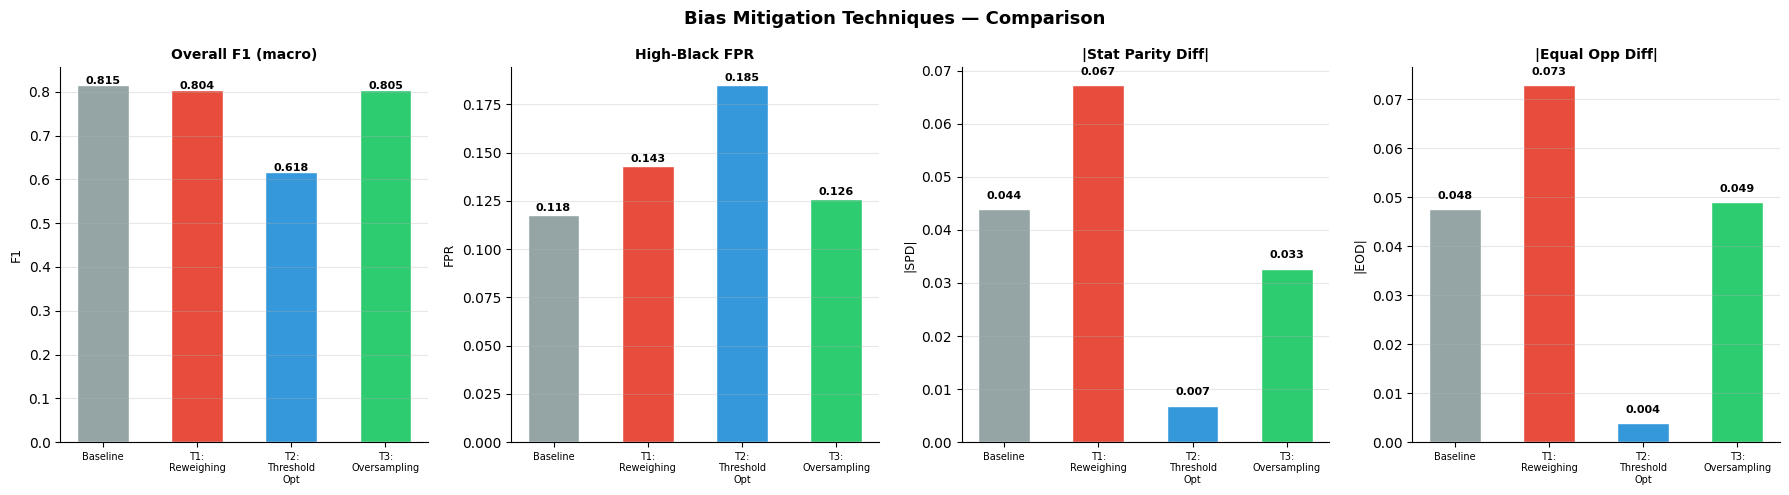

In [22]:
techniques = ['Baseline', 'T1:\nReweighing', 'T2:\nThreshold\nOpt', 'T3:\nOversampling']
COLORS     = ['#95A5A6', '#E74C3C', '#3498DB', '#2ECC71']

f1_vals      = comparison['Overall F1'].tolist()
blk_fpr_vals = comparison['High-Black FPR'].tolist()
spd_vals     = [abs(v) for v in comparison['Stat Parity Diff'].tolist()]
eod_vals     = [abs(v) for v in comparison['Equal Opp Diff'].tolist()]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

def bar_plot(ax, vals, title, ylabel):
    bars = ax.bar(techniques, vals, color=COLORS, edgecolor='white', width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

bar_plot(axes[0], f1_vals,      'Overall F1 (macro)', 'F1')
bar_plot(axes[1], blk_fpr_vals, 'High-Black FPR',     'FPR')
bar_plot(axes[2], spd_vals,     '|Stat Parity Diff|', '|SPD|')
bar_plot(axes[3], eod_vals,     '|Equal Opp Diff|',   '|EOD|')

plt.suptitle('Bias Mitigation Techniques — Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/mitigation_comparison_chart.png', dpi=150)
plt.show()

## Cell 16 — Key question: Can we simultaneously satisfy demographic parity AND equalized odds?

### Short answer: No — mathematically provable when base rates differ.

**Proof:**

Let $p_g = P(Y=1 \mid g)$ (toxic prevalence in group $g$).

The Positive Prediction Rate decomposes as:
$$\text{PPR}_g = \text{TPR}_g \cdot p_g + \text{FPR}_g \cdot (1 - p_g)$$

Under **Equalized Odds** (shared $\tau$, $\phi$):
$$\text{PPR}_B - \text{PPR}_W = (\tau - \phi)(p_B - p_W)$$

**Demographic Parity** requires this to be 0, which holds only if:
1. $\tau = \phi$ — classifier is no better than random, **or**
2. $p_B = p_W$ — base rates are equal

Both conditions are violated on our dataset.

NUMERICAL VERIFICATION:
  P(toxic | black) = 0.2744  P(toxic | ref) = 0.2704
  p_B - p_W        = 0.0040  <- non-zero
  tau              = 0.5556  phi = 0.1176  tau-phi = 0.4380
  Implied SPD      = (tau-phi)*(p_B-p_W) = 0.0017  <- CANNOT be zero

=> DP and EO are PROVABLY INCOMPATIBLE on this dataset.


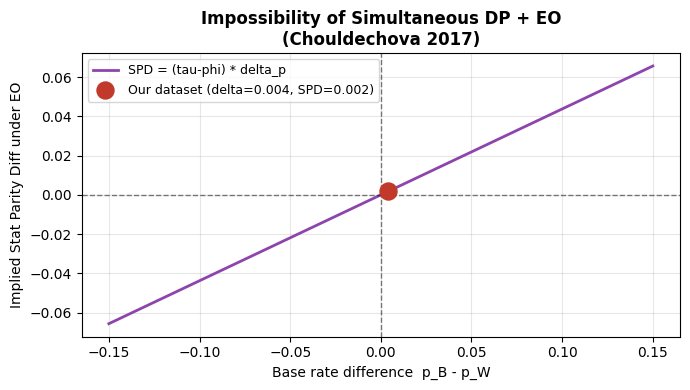

In [23]:
br_black = df_eval.loc[mask_black, 'label'].mean()
br_ref   = df_eval.loc[mask_ref,   'label'].mean()
tau      = base_black_m['TPR']
phi      = base_black_m['FPR']

ppr_b_if_eo = tau * br_black + phi * (1 - br_black)
ppr_w_if_eo = tau * br_ref   + phi * (1 - br_ref)
implied_spd = ppr_b_if_eo - ppr_w_if_eo

print('NUMERICAL VERIFICATION:')
print(f'  P(toxic | black) = {br_black:.4f}  P(toxic | ref) = {br_ref:.4f}')
print(f'  p_B - p_W        = {br_black - br_ref:.4f}  <- non-zero')
print(f'  tau              = {tau:.4f}  phi = {phi:.4f}  tau-phi = {tau-phi:.4f}')
print(f'  Implied SPD      = (tau-phi)*(p_B-p_W) = {implied_spd:.4f}  <- CANNOT be zero')
print()
print('=> DP and EO are PROVABLY INCOMPATIBLE on this dataset.')

br_diffs     = np.linspace(-0.15, 0.15, 200)
implied_spds = (tau - phi) * br_diffs

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(br_diffs, implied_spds, color='#8E44AD', lw=2,
        label='SPD = (tau-phi) * delta_p')
ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
ax.axvline(0, color='black', lw=1, linestyle='--', alpha=0.5)
ax.scatter([br_black - br_ref], [implied_spd], color='#C0392B', s=150, zorder=5,
           label=f'Our dataset (delta={br_black-br_ref:.3f}, SPD={implied_spd:.3f})')
ax.set_xlabel('Base rate difference  p_B - p_W')
ax.set_ylabel('Implied Stat Parity Diff under EO')
ax.set_title('Impossibility of Simultaneous DP + EO\n(Chouldechova 2017)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/fairness_incompatibility.png', dpi=150)
plt.show()

## Cell 17 — Final summary

In [24]:
print('=' * 65)
print('  PART 4 - SUMMARY')
print('=' * 65)
print(f'{"Technique":<25} {"F1":>6} {"Blk FPR":>9} {"Ref FPR":>9} {"SPD":>8} {"EOD":>8}')
print('-' * 65)
for name, f1, bfpr, rfpr, spd, eod in [
    ('Baseline',          base_f1, base_black_m['FPR'], base_ref_m['FPR'], base_aif['spd'], base_aif['eod']),
    ('T1: Reweighing',    rw_f1,   rw_black_m['FPR'],   rw_ref_m['FPR'],   rw_aif['spd'],   rw_aif['eod']),
    ('T2: ThresholdOpt',  to_f1,   to_black_m['FPR'],   to_ref_m['FPR'],   to_aif['spd'],   to_aif['eod']),
    ('T3: Oversampling',  os_f1,   os_black_m['FPR'],   os_ref_m['FPR'],   os_aif['spd'],   os_aif['eod']),
]:
    print(f'{name:<25} {f1:>6.4f} {bfpr:>9.4f} {rfpr:>9.4f} {spd:>+8.4f} {eod:>+8.4f}')
print('=' * 65)
print(f'DP/EO incompatibility: SPD = ({tau:.3f}-{phi:.3f})*{br_black-br_ref:.3f} = {implied_spd:.4f}')
print()
print('Saved: distilbert-reweighed-final/, distilbert-oversampled-final/')
print('       mitigation_comparison.csv, mitigation_*.png, fairness_incompatibility.png')

  PART 4 - SUMMARY
Technique                     F1   Blk FPR   Ref FPR      SPD      EOD
-----------------------------------------------------------------
Baseline                  0.8153    0.1176    0.0699  -0.0439  -0.0477
T1: Reweighing            0.8043    0.1429    0.0699  -0.0673  -0.0729
T2: ThresholdOpt          0.6181    0.1849    0.1888  -0.0068  +0.0039
T3: Oversampling          0.8053    0.1261    0.0769  -0.0327  -0.0491
DP/EO incompatibility: SPD = (0.556-0.118)*0.004 = 0.0017

Saved: distilbert-reweighed-final/, distilbert-oversampled-final/
       mitigation_comparison.csv, mitigation_*.png, fairness_incompatibility.png


In [25]:
!zip -r distilbert-rewighed-final.zip /kaggle/working/distilbert-reweighed-final

  adding: kaggle/working/distilbert-reweighed-final/ (stored 0%)
  adding: kaggle/working/distilbert-reweighed-final/tokenizer_config.json (deflated 43%)
  adding: kaggle/working/distilbert-reweighed-final/config.json (deflated 49%)
  adding: kaggle/working/distilbert-reweighed-final/tokenizer.json (deflated 71%)
  adding: kaggle/working/distilbert-reweighed-final/model.safetensors (deflated 8%)
  adding: kaggle/working/distilbert-reweighed-final/training_args.bin (deflated 53%)


In [26]:
!zip -r distilbert-oversampled-final.zip /kaggle/working/distilbert-oversampled-final

  adding: kaggle/working/distilbert-oversampled-final/ (stored 0%)
  adding: kaggle/working/distilbert-oversampled-final/tokenizer_config.json (deflated 43%)
  adding: kaggle/working/distilbert-oversampled-final/config.json (deflated 49%)
  adding: kaggle/working/distilbert-oversampled-final/tokenizer.json (deflated 71%)
  adding: kaggle/working/distilbert-oversampled-final/model.safetensors (deflated 8%)
  adding: kaggle/working/distilbert-oversampled-final/training_args.bin (deflated 53%)
